# **Section 1**

## Question 1: Risk Factor Identification



### Visual Inspection

The time series $\{x_t\}_{t=0}^{N}$ of observations of the daily price of the underlying asset is modeled by the following stochastic differential equation:

$$
dX_t = \kappa X_t \, dt + \sigma \sqrt{X_t} \, dW_t^{\mathbb{Q}}
$$

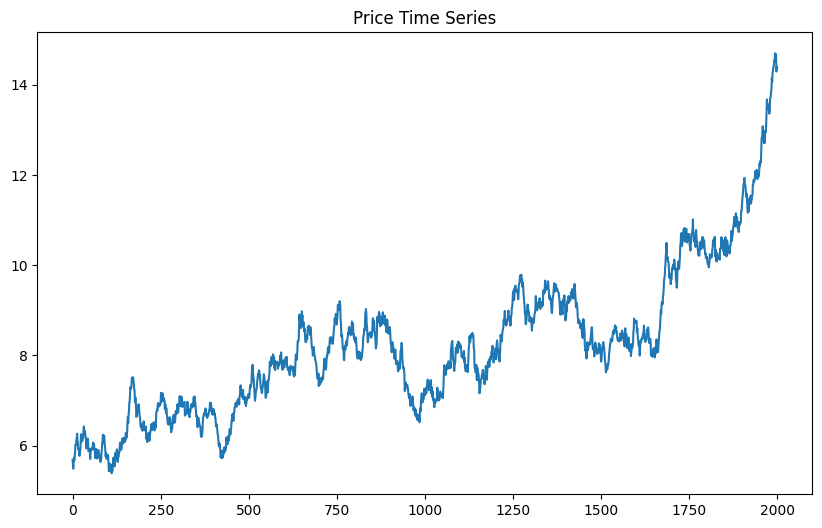

In [117]:
#from google.colab import files
#uploaded = files.upload()
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import norm
import scipy.stats as stats
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize

data= pd.read_excel('Group2_12465_prices.xlsx')
data['X(t)'].plot(title='Price Time Series', figsize=(10, 6))
plt.show()


### Interpretation

The previous structure is reminiscent of the Cox-Ingersoll-Ross
(CIR) model typically used for interest rates to prevent negative values. However, the drift term $\kappa x_t$ implies
a geometric growth (or decay) proportional to the current level, typical of equity models like Black-Scholes.
Therefore, X reasonably represents a **stock price** or a **commodity index** characterized by a *“leverage effect”*

In [118]:
# Constants from the assignment
DAYS_PER_YEAR = 250
dt = 1 / DAYS_PER_YEAR
T = 0.6
r = 0.02
B = 22 # Barrier

# TS
x_series = data['X(t)'].values
x_0 = x_series[0]
x_N = x_series[-1]

print(f"Number of observations: {len(x_series)}")
print(f"Last observed price (x_N): {x_N}")

Number of observations: 2001
Last observed price (x_N): 14.396185103734336


## Question 2: Distribution of Standardized Shocks

### Euler Discretization

$$
X_{t+\Delta t} = X_t + \kappa X_t \Delta t + \sigma \sqrt{X_t}\sqrt{\Delta t}\, z_{t+1}
$$

$$
z_{t+1}=
\frac{X_{t+\Delta t}-X_t-\kappa X_t\Delta t}{\sigma \sqrt{X_t\Delta t}}
$$

Based on the literature, we made the following guesses:
- $\kappa = 0.1$
- $\sigma = 0.3$

### Visualization

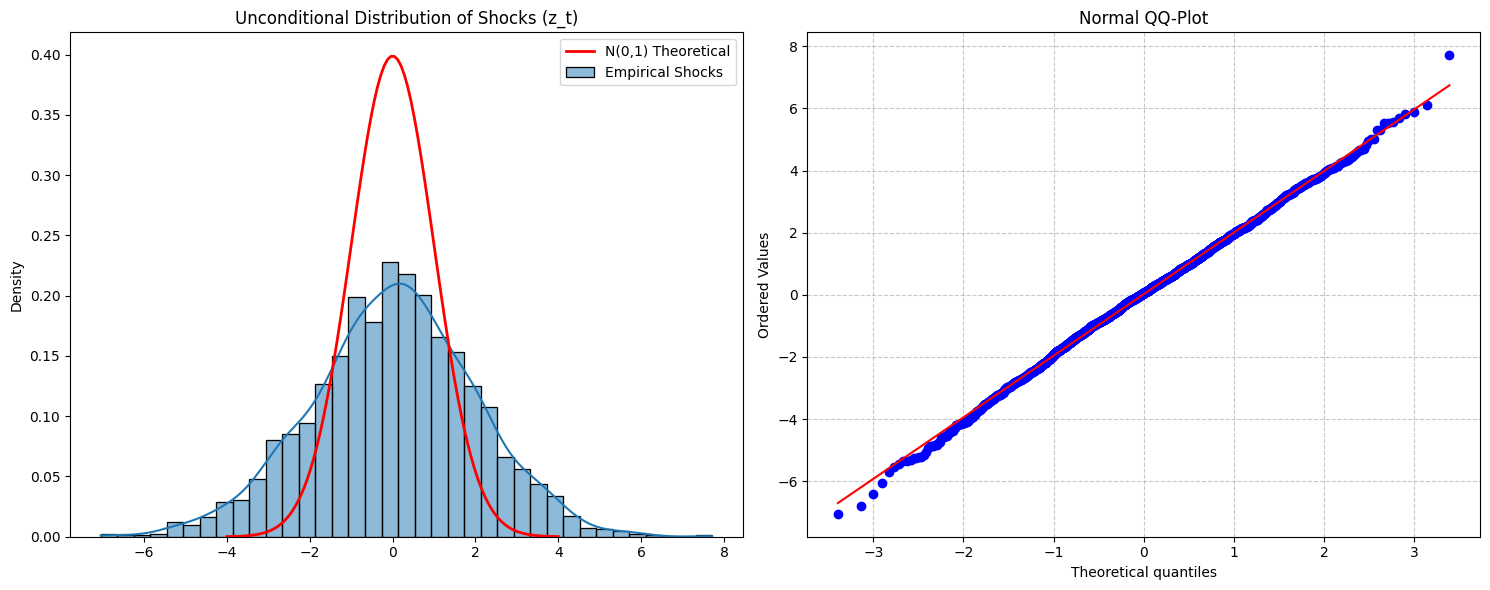

Shocks Mean: 0.0207 (Expected 0)
Shocks Std Dev: 1.9803 (Expected 1)


In [119]:
# Initial Guesses
kappa_guess = 0.1
sigma_guess = 0.3

# Shocks Z_t
shocks = []
for t in range(len(x_series) - 1):
    numerator = x_series[t+1] - x_series[t] - kappa_guess * x_series[t] * dt
    denominator = sigma_guess * np.sqrt(x_series[t] * dt)
    shocks.append(numerator / denominator)

shocks = np.array(shocks)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(shocks, kde=True, stat="density", label='Empirical Shocks', ax=ax1)

# Unconditional Distribution Plot
x_axis = np.linspace(-4, 4, 100)
ax1.plot(x_axis, norm.pdf(x_axis, 0, 1), 'r', lw=2, label='N(0,1) Theoretical')
ax1.set_title("Unconditional Distribution of Shocks (z_t)")
ax1.legend()

# QQ-Plot
stats.probplot(shocks, dist="norm", plot=ax2)
ax2.set_title("Normal QQ-Plot")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Shocks Mean: {np.mean(shocks):.4f} (Expected 0)")
print(f"Shocks Std Dev: {np.std(shocks):.4f} (Expected 1)")

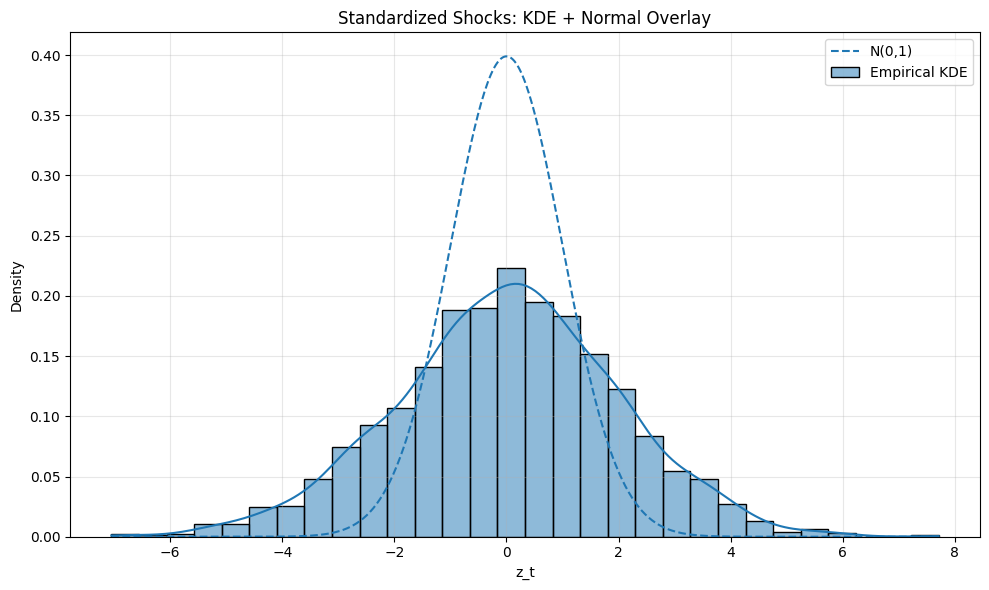

In [120]:
shocks = np.asarray(shocks)

plt.figure(figsize=(10, 6))

# Histogram + KDE
sns.histplot(shocks, bins=30, stat="density", kde=True, label="Empirical KDE")

# Theoric Normal N(0,1) pdf overlay
x = np.linspace(shocks.min(), shocks.max(), 500)
plt.plot(x, norm.pdf(x, 0, 1), linestyle="--", label="N(0,1)")

plt.title("Standardized Shocks: KDE + Normal Overlay")
plt.xlabel("z_t")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Result

- $\mu = 0.0207$
- $\sigma = 1.9803$

## Question 3: MLE Estimation

### Optimal Parameter

Relying on the normality of $z_t$, the transition density of $X_{t+\Delta t}$ given $X_t$ is approximately normal with:

* Mean: $\mu_t = X_t + \kappa X_t \Delta t$
* Variance: $v_t = \sigma^2 X_t \Delta t$

The negative log-likelihood function was constructed as:

$$
-\ln L(\theta) = \frac{1}{2} \sum_{t=0}^{N-1} \left[ \ln(2\pi v_t) + \frac{(X_{t+1} - \mu_t)^2}{v_t} \right]
$$

Minimizing this function yields the optimal parameter set $\Theta = (\kappa, \sigma)$.

In [121]:
def log_likelihood(params, series, dt):
    kappa, sigma = params
    if kappa < 0 or sigma <= 0:
        return 1e10 # Constraint: parameters must be non-negative

    n = len(series) - 1
    ll = 0 # ll = log likelihood
    for t in range(n):
        x_t = series[t]
        x_next = series[t+1]


        mu = x_t + kappa * x_t * dt
        var = (sigma**2) * x_t * dt

        ll += -0.5 * np.log(2 * np.pi * var) - 0.5 * ((x_next - mu)**2 / var)

    return -ll # Minimize negative log-likelihood

initial_guess = [0.1, 0.2]
result = minimize(log_likelihood, initial_guess, args=(x_series, dt))

kappa_mle, sigma_mle = result.x
print(f"Estimated Kappa: {kappa_mle:.6f}")
print(f"Estimated Sigma: {sigma_mle:.6f}")

Estimated Kappa: 0.132328
Estimated Sigma: 0.594098


### Estimated Parameters

* $\hat{\kappa}_{\text{MLE}} \approx 0.1323$
* $\hat{\sigma}_{\text{MLE}} \approx 0.5941$

# **Section 2**

## Question 4: Monte Carlo Pricing

### Vanilla Call Option Characteristics

We proceed to price a plain vanilla European Call Option with the following characteristics:
* Maturity (*T* ): 0.6 years
* Strike (*K* ): *X*(0) = $x_N$ (At-the-money based on the last observed price)
* Risk-free rate ($r$): 2%

In [122]:
np.random.seed(42)
n_sims = 100000 # Number of Monte Carlo simulations
n_steps = int(T * DAYS_PER_YEAR)
dt_mc = T / n_steps
strike = x_N # K = X(0) = x_N

# Simulation of paths
paths = np.zeros((n_sims, n_steps + 1))
paths[:, 0] = x_N

for t in range(n_steps):
    z = np.random.standard_normal(n_sims)
    # Euler step: dXt = kappa*Xt*dt + sigma*sqrt(Xt)*dWt
    paths[:, t+1] = paths[:, t] + kappa_mle * paths[:, t] * dt_mc + \
                    sigma_mle * np.sqrt(np.maximum(paths[:, t], 0)) * np.sqrt(dt_mc) * z

# Calculate Payoff at T
payoffs = np.maximum(paths[:, -1] - strike, 0)
call_mc = np.exp(-r * T) * np.mean(payoffs)

print(f"Monte Carlo Price (European Call): {call_mc:.4f}")

Monte Carlo Price (European Call): 1.4514


### Visualization of MC Simulations

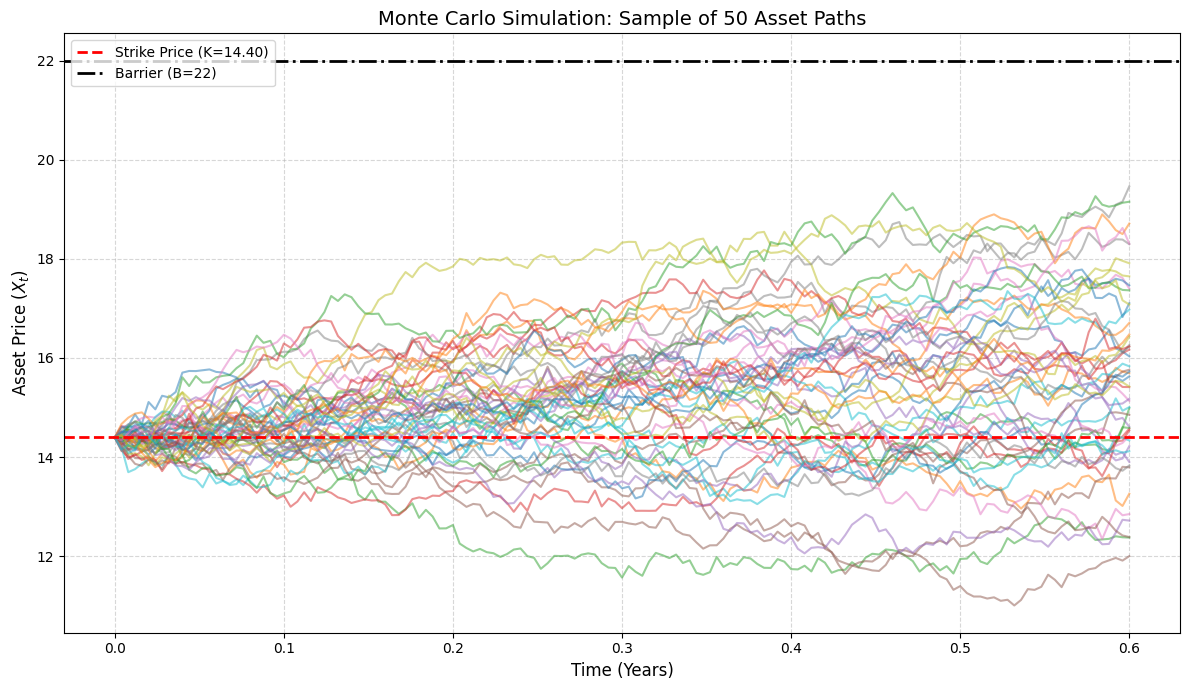

In [123]:
# Plot of MC Simulation
plt.figure(figsize=(12, 7))
time_grid = np.linspace(0, T, n_steps + 1)
num_paths_to_plot = 50

plt.plot(time_grid, paths[:num_paths_to_plot, :].T, lw=1.5, alpha=0.5)
plt.axhline(y=strike, color='red', linestyle='--', linewidth=2, label=f'Strike Price (K={strike:.2f})')
plt.axhline(y=B, color='black', linestyle='-.', linewidth=2, label=f'Barrier (B={B})')

plt.title(f"Monte Carlo Simulation: Sample of {num_paths_to_plot} Asset Paths", fontsize=14)
plt.xlabel("Time (Years)", fontsize=12)
plt.ylabel("Asset Price ($X_t$)", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Result

The price is estimated as the discounted expectation of the terminal payoff:

$$
\pi_0^E \approx e^{-rT} \frac{1}{N_{\text{sim}}} \sum_{i=1}^{N_{\text{sim}}} \max(X_T^{(i)} - K, 0)
$$

The MC simulation provides us with a price equal to 1.4514

## Question 5: Lattice Pricing (Binomial Tree)

### Binomial Tree Parameters:
- $N_{steps}=300$
- Up movement: $u=\exp\!\left(\frac{\sigma\sqrt{\Delta t}}{\sqrt{X_0}}\right)$
- Down movement: $d=\frac{1}{u}$
- Probability of an up-move $p$ derived from the risk-neutral drift: $p=\frac{\exp(\hat{\kappa}_{MLE} \cdot \frac{T}{N_{steps}})-d}{u-d}$



### Invertible Transformation Method

We find:

$$dY_t=\left( \frac{\kappa}{2}Y_t-\frac{\sigma^2}{2\cdot Y_t} \right)\cdot dt + \sigma\cdot dW_t$$

In [124]:
# Transformation and inverse
# f(x) = 2*sqrt(x)
# f^{-1}(y) = (y/2)^2

n_tree_steps = 300
dt_tree = T / n_tree_steps
u = np.exp(sigma_mle * np.sqrt(dt_tree) / np.sqrt(x_N)) # Simplified approximation
d = 1/u
p = (np.exp(kappa_mle * dt_tree) - d) / (u - d)


tree_prices = np.zeros(n_tree_steps + 1)
for j in range(n_tree_steps + 1):
    tree_prices[j] = x_N * (u**j) * (d**(n_tree_steps - j))

def f_transform(x):
    return 2 * np.sqrt(np.maximum(x, 1e-12))

def f_inverse(y):
    return (y / 2) ** 2

Y0 = f_transform(x_N)
Y_tree = np.zeros((n_tree_steps + 1, n_tree_steps + 1))

for col in range(n_tree_steps + 1):
    for row in range(col + 1):
        Y_tree[row, col] = Y0 + sigma_mle * np.sqrt(dt_tree) * (col - 2 * row)

X_tree = f_inverse(Y_tree)


drift_tree = (kappa_mle * np.sqrt(np.maximum(X_tree, 1e-12))
              - sigma_mle**2 / (4 * np.sqrt(np.maximum(X_tree, 1e-12)))) # Applying Ito's Lemma


prob_tree = np.clip(
    0.5 + drift_tree * np.sqrt(dt_tree) / (2 * sigma_mle),
    0, 1 )

option_tree = np.zeros((n_tree_steps + 1, n_tree_steps + 1))
option_tree[:, -1] = np.maximum(X_tree[:, -1] - strike, 0)

disc = np.exp(-r * dt_tree)

for col in range(n_tree_steps - 1, -1, -1):
    for row in range(col + 1):
        q  = prob_tree[row, col]
        Vu = option_tree[row,     col + 1]
        Vd = option_tree[row + 1, col + 1]
        option_tree[row, col] = disc * (q * Vu + (1 - q) * Vd)

call_lattice = option_tree[0, 0]
print(f"Lattice Price (European Call): {call_lattice:.4f}")

Lattice Price (European Call): 1.4512


### Result

The Binomial Tree methodology provides us with a price equal to 1.4512

## Question 6: Finite Difference Method (Explicit)

### Building Up the Grid

- Asset price domain: $S_{max}=x_N \cdot 3$
- Price Steps: $M=100$
- Time Steps: $N=10000$

### Discretized PDE Coefficients

The continuous derivatives were replaced by finite difference approximations (gamma, theta).

$$\gamma_i = \frac{\sigma^2 S_i}{2 (\Delta S)^2}\Delta t,
\qquad \theta_i = \frac{\kappa S_i}{2 \Delta S}\Delta t $$

### Boundary Conditions

- $V(S,T)=\max(S-K,0)$ (Terminal condition)
- $V(0,t)=0$ (Call value at zero asset price)
- $V(S_{\max},t)\approx S_{\max}-K e^{-r(T-t)}$ (Linearity for deep ITM calls)

In [125]:
X_max = x_N * 3
mx    = 100
mt    = 10000

x_grid, dx    = np.linspace(0, X_max, mx + 1, retstep=True)
t_grid, dt_fd = np.linspace(0, T, mt + 1, retstep=True)


mu_x     = kappa_mle * x_grid # mu(X)       = kappa * X
sigma2_x = sigma_mle**2 * x_grid # sigma^2(X)  = sigma_mle^2 * X

# Central difference Method
a_central = dt_fd * (0.5 * sigma2_x / dx**2 - mu_x / (2 * dx))
b_central = 1 - dt_fd * (sigma2_x / dx**2 + r)
c_central = dt_fd * (0.5 * sigma2_x / dx**2 + mu_x / (2 * dx))

call_grid_c = np.zeros((mt + 1, mx + 1))
call_grid_c[:, 0]  = 0
call_grid_c[:, -1] = X_max - strike * np.exp(-r * t_grid)
call_grid_c[-1, :] = np.maximum(x_grid - strike, 0)

for i in range(1, mt + 1):
    for j in range(1, mx):

        call_grid_c[mt - i, j] = (call_grid_c[mt - i + 1, j - 1] * a_central[j] +
                                   call_grid_c[mt - i + 1, j]     * b_central[j] +
                                   call_grid_c[mt - i + 1, j + 1] * c_central[j])

call_fd_central = np.interp(x_N, x_grid, call_grid_c[0])

print(f"Finite Difference Price (central): {call_fd_central:.4f}")

Finite Difference Price (central): 1.4536


### Result

The Finite Difference Methodology provides us with a price equal to 1.4521

### Convergence Plot of Numerical Methods

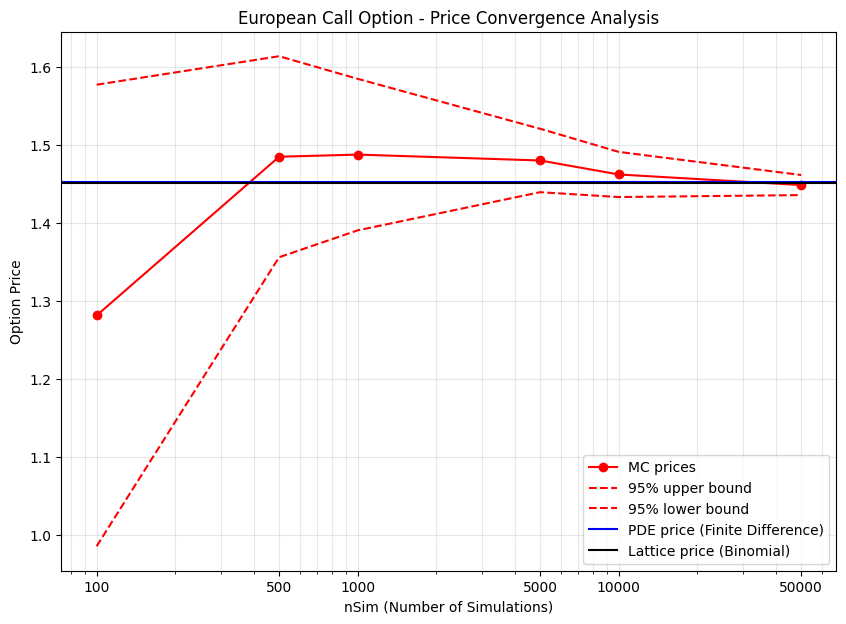

In [126]:
nsim_list = [100, 500, 1000, 5000, 10000, 50000] # List of number of simulations to test for convergence
mc_prices = []
upper_bounds = []
lower_bounds = []


for n_sims_val in nsim_list:

    temp_paths = np.zeros((n_sims_val, n_steps + 1))
    temp_paths[:, 0] = x_N

    for t in range(n_steps):
        z_val = np.random.standard_normal(n_sims_val)
        temp_paths[:, t+1] = temp_paths[:, t] + kappa_mle * temp_paths[:, t] * dt_mc + \
                             sigma_mle * np.sqrt(np.maximum(temp_paths[:, t], 0)) * np.sqrt(dt_mc) * z_val

    # Discounted Payoffs
    temp_payoffs = np.exp(-r * T) * np.maximum(temp_paths[:, -1] - strike, 0)

    # Mean price
    m_price = np.mean(temp_payoffs)

    # Standard Error for 95% Confidence Interval
    std_err = stats.sem(temp_payoffs)
    mc_prices.append(m_price)
    upper_bounds.append(m_price + 1.96 * std_err)
    lower_bounds.append(m_price - 1.96 * std_err)

plt.figure(figsize=(10, 7))

plt.plot(nsim_list, mc_prices, 'r-', label='MC prices', marker='o')
plt.plot(nsim_list, upper_bounds, 'r--', label='95% upper bound')
plt.plot(nsim_list, lower_bounds, 'r--', label='95% lower bound')

# Horizontal benchmarks
plt.axhline(y=call_fd_central, color='b', linestyle='-', label='PDE price (Finite Difference)')
plt.axhline(y=call_lattice, color='k', linestyle='-', label='Lattice price (Binomial)')

plt.xscale('log') # Logarithmic scale for better visibility of convergence
plt.xticks(nsim_list, labels=[str(x) for x in nsim_list])
plt.xlabel('nSim (Number of Simulations)')
plt.ylabel('Option Price')
plt.title('European Call Option - Price Convergence Analysis')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

# **Section 3**

## Question 7: American Call Price



In [127]:
option_tree_am = np.zeros((n_tree_steps + 1, n_tree_steps + 1))
option_tree_am[:, -1] = np.maximum(X_tree[:, -1] - strike, 0)

for col in range(n_tree_steps - 1, -1, -1):
    for row in range(col + 1):
        q            = prob_tree[row, col]
        Vu           = option_tree_am[row,     col + 1]
        Vd           = option_tree_am[row + 1, col + 1]
        continuation = disc * (q * Vu + (1 - q) * Vd)
        exercise_now = max(X_tree[row, col] - strike, 0.0)
        option_tree_am[row, col] = max(continuation, exercise_now)

call_american  = option_tree_am[0, 0]
early_premium  = call_american - call_lattice
print(f"American Call Price:    {call_american:.4f}")
print(f"Early Exercise Premium: {early_premium:.4f}")

American Call Price:    1.4512
Early Exercise Premium: 0.0000


### Results

- American Call Price: $1.4512$ (slightly less than European Call)
- Early Exercise Premium: $0.0000$

### Lattice methodology: Visualization of American Call Lattice Decisions

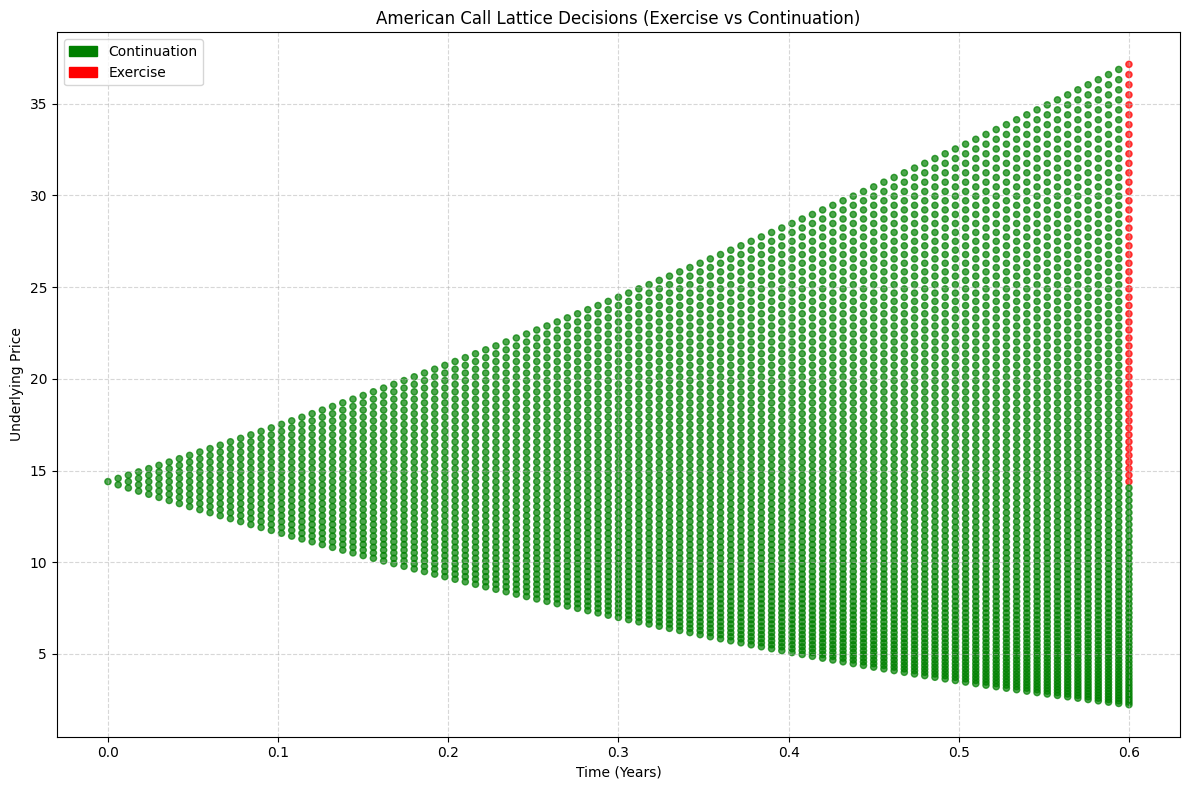

In [128]:
N_plot   = 100
dt_plot  = T / N_plot

Y0_plot  = f_transform(x_N)
Y_plot   = np.zeros((N_plot + 1, N_plot + 1))
for col in range(N_plot + 1):
    for row in range(col + 1):
        Y_plot[row, col] = Y0_plot + sigma_mle * np.sqrt(dt_plot) * (col - 2 * row)

X_plot = f_inverse(Y_plot)

drift_plot = (kappa_mle * np.sqrt(np.maximum(X_plot, 1e-12))
              - sigma_mle**2 / (4 * np.sqrt(np.maximum(X_plot, 1e-12))))
prob_plot  = np.clip(
    0.5 + drift_plot * np.sqrt(dt_plot) / (2 * sigma_mle),
    0, 1
)

v_plot = np.zeros((N_plot + 1, N_plot + 1))
v_plot[:, -1] = np.maximum(X_plot[:, -1] - strike, 0)
decisions = np.zeros((N_plot + 1, N_plot + 1))
decisions[:, -1] = np.where(X_plot[:, -1] > strike, 1, 0)

disc_plot = np.exp(-r * dt_plot)

for col in range(N_plot - 1, -1, -1):
    for row in range(col + 1):
        q            = prob_plot[row, col]
        Vu           = v_plot[row,     col + 1]
        Vd           = v_plot[row + 1, col + 1]
        continuation = disc_plot * (q * Vu + (1 - q) * Vd)
        exercise_now = max(X_plot[row, col] - strike, 0.0)
        if exercise_now > continuation and exercise_now > 0:
            v_plot[row, col] = exercise_now
            decisions[row, col] = 1
        else:
            v_plot[row, col] = continuation
            decisions[row, col] = 0

time_coords, price_coords, colors_plot = [], [], []
for col in range(N_plot + 1):
    for row in range(col + 1):
        time_coords.append(col * dt_plot)
        price_coords.append(X_plot[row, col])
        colors_plot.append('red' if decisions[row, col] == 1 else 'green')

plt.figure(figsize=(12, 8))
plt.scatter(time_coords, price_coords, c=colors_plot, s=20, alpha=0.7)
green_patch = mpatches.Patch(color='green', label='Continuation')
red_patch   = mpatches.Patch(color='red',   label='Exercise')
plt.legend(handles=[green_patch, red_patch])
plt.title("American Call Lattice Decisions (Exercise vs Continuation)")
plt.xlabel("Time (Years)")
plt.ylabel("Underlying Price")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Question 8: Up-and-Out Barrier Call

In [129]:
barrier_breached = np.any(paths >= B, axis=1)
payoffs_barrier = np.maximum(paths[:, -1] - strike, 0)
payoffs_barrier[barrier_breached] = 0

call_barrier = np.exp(-r * T) * np.mean(payoffs_barrier)
print(f"Up-and-Out Barrier Call Price (B=22): {call_barrier:.4f}")

Up-and-Out Barrier Call Price (B=22): 1.4438


### Result

- Up-and-Out Barrier Call Price ($B=22$): $1.4438$

### Up-and-Out Call Payoff Visualization

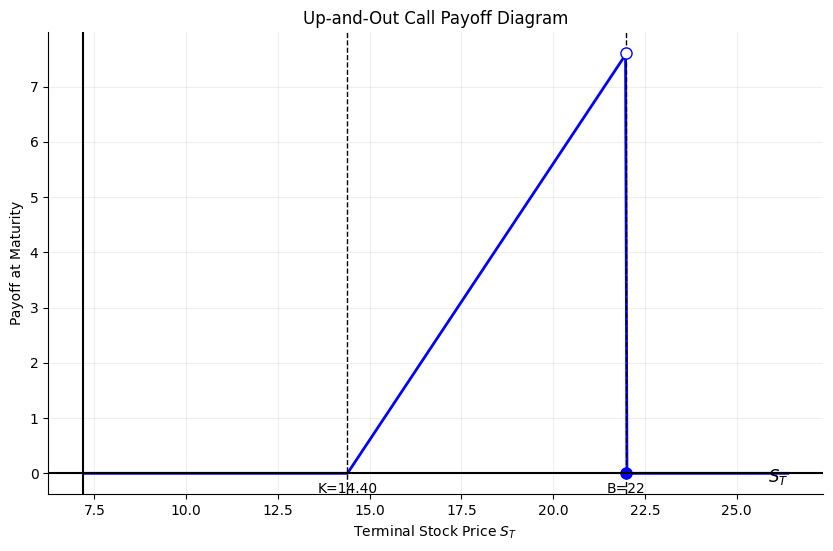

In [130]:
s_terminal = np.linspace(x_N * 0.5, B * 1.2, 500)

payoff_up_and_out = np.where((s_terminal > strike) & (s_terminal < B), s_terminal - strike, 0)

plt.figure(figsize=(10, 6))

plt.plot(s_terminal, payoff_up_and_out, color='blue', lw=2)

plt.axvline(x=strike, color='black', linestyle='--', lw=1)
plt.axvline(x=B, color='black', linestyle='--', lw=1)

plt.plot(B, B - strike, marker='o', markerfacecolor='white', markeredgecolor='blue', markersize=8)
plt.plot(B, 0, marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=8)

plt.text(strike, -0.02 * (B-strike), f'K={strike:.2f}', ha='center', va='top', fontsize=10)
plt.text(B, -0.02 * (B-strike), f'B={B}', ha='center', va='top', fontsize=10)
plt.text(s_terminal[-1], -0.02 * (B-strike), '$S_T$', ha='right', fontsize=12)

plt.axhline(0, color='black', lw=1.5) # X-axis
plt.axvline(s_terminal[0], color='black', lw=1.5) # Y-axis
plt.title("Up-and-Out Call Payoff Diagram")
plt.ylabel("Payoff at Maturity")
plt.xlabel("Terminal Stock Price $S_T$")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, alpha=0.2)

plt.show()